# Out-of-Distribution (OOD) Detection in Medical Imaging Using Deep Learning 🌀

**Part 3 — Evaluation of Uncertainty**

> *A model can only be trusted when it knows the limits of what it knows. OOD detection is the mechanism that enforces those limits.*

<div align="center" style="margin-top: 50px;"> <img src="https://raw.githubusercontent.com/benyamin-gheiji/Uncertainty-Quantification-Medical-Imaging-Analysis/main/session%2018/intro.png" width="700" /> </div>

---

### What this notebook covers

- The **clinical motivation** for OOD detection in deployed medical AI
- **Framing OOD detection as binary classification** — ID vs OOD over inputs
- **Evaluation metrics**: AUROC, AUPRC, FPR@95%TPR — explained in clinical terms
- **OOD data construction**: simulated corruptions representing real clinical distribution shifts
- **Per-method OOD evaluation**: VI, MC Dropout, Deep Ensembles, EDL, and Conformal Prediction — each using its own uncertainty signal as the OOD score
- **Qualitative visualization**: ID vs OOD chest X-rays with their uncertainty scores
- A summary reframing uncertainty as a **binary safety screening task**

---

## 🏥 Part 1 — Clinical motivation

### What happens when AI sees something it was never trained on

A chest X-ray AI system trained at Hospital A is deployed at Hospital B. Hospital B uses a different scanner manufacturer, a different acquisition protocol, and serves a slightly different patient demographic. The images look similar to a clinician — but to the model, the feature distributions are shifted in ways the training data never prepared it for.

What does the model do? In most current systems: it processes every image as if it were in-distribution and produces confident-looking predictions. There is no mechanism to detect that anything is different. Clinicians receive probability scores that look authoritative but are generated by a model operating outside its validated operating envelope.

This is not a hypothetical risk. It is one of the most commonly cited failure modes in real-world clinical AI deployments. And it is precisely the kind of failure that uncertainty quantification should prevent — but often doesn't, unless the system is explicitly designed and tested for OOD detection.

---

### The clinical scenarios where OOD detection matters

| Scenario | Distribution shift type | Clinical risk |
|---|---|---|
| Different scanner manufacturer | Feature distribution shift | Model learned scanner-specific artifacts |
| Different acquisition protocol | Contrast / brightness shift | Intensity statistics differ from training |
| Poor image quality | Technical quality shift | Motion blur, underexposure, noise |
| Rare or unseen pathology | Semantic shift | Model has no training examples of this condition |
| Different age group or demographics | Population shift | Anatomy and presentation patterns differ |
| Post-surgical or implant artifacts | Structural shift | Metal artifacts, surgical clips, catheters |

In each case, the question is the same: **can the model detect that something is off before producing a prediction that might be wrong?** OOD detection reframes uncertainty quantification as a binary safety screening task — the first gate a clinical AI system should pass every input through.

---

> **🏥 Clinical analogy**  
> A radiologist encountering an unusual scan they haven't seen before does not produce a confident report pretending otherwise. They flag it: *"Unusual presentation — recommend clinical correlation or specialist review."* That is the behaviour we want from an AI system. OOD detection is the mechanism that enables it.

---

## 📐 Part 2 — Problem formulation

### OOD detection as binary classification over inputs

Ordinarily, a classifier produces a label over the output space: *"this image is Normal or Pneumonia."* OOD detection is a different kind of classifier — it operates over the **input space** and produces a binary label:

$$\text{OOD score}(x) \rightarrow \text{flag as OOD?} \in \{\text{ID, OOD}\}$$

The OOD score is derived from whatever uncertainty signal the model produces:
- Predictive entropy, variance, mutual information for VI / MC Dropout / Ensembles
- Evidence strength $S$ (inverted) or $u = K/S$ for EDL
- Nonconformity score or set size for Conformal Prediction

The key assumption: **higher uncertainty should indicate OOD**. An ID input that the model knows well should produce low uncertainty. An OOD input — something the model has never been trained on — should produce high uncertainty. Whether this assumption holds is exactly what this notebook tests.

---

### The evaluation pipeline

Given a set of ID samples and a set of OOD samples, we:
1. Compute the OOD score for every sample using each method's uncertainty output
2. Assign labels: ID = 0, OOD = 1
3. Treat this as a standard binary classification problem and evaluate with the metrics below

No disease classification happens here. The only task is: *does the uncertainty score separate ID from OOD?*

---

## 📊 Part 3 — Evaluation metrics

### AUROC — Primary separability metric

The Area Under the Receiver Operating Characteristic curve measures the probability that a randomly chosen OOD input has a higher uncertainty score than a randomly chosen ID input:

$$\text{AUROC} = P(\text{score}_{\text{OOD}} > \text{score}_{\text{ID}})$$

- **AUROC = 1.0:** perfect separation — every OOD input has a higher score than every ID input
- **AUROC = 0.5:** random — the score provides no information about ID vs OOD
- **AUROC < 0.5:** worse than random — the score is inverted (use 1 - score)

**Clinical interpretation:** AUROC = 0.85 means that if you pick one OOD scan and one ID scan at random, 85% of the time the AI correctly assigns a higher suspicion score to the OOD scan.

---

### AUPRC — Precision-Recall metric for rare OOD

When OOD samples are rare — as they should be in a well-functioning clinical system — AUROC can be misleading because it is symmetric over the class imbalance. AUPRC (Area Under the Precision-Recall Curve) is more informative in this regime.

**Clinical interpretation:** AUPRC measures how precisely the system flags OOD samples — how often a flagged scan actually is OOD (precision), across different sensitivity levels (recall). A high AUPRC means fewer false alarms — fewer normal ID scans incorrectly routed to specialist review.

---

### FPR@95%TPR — Safety-oriented operating metric

At the threshold where 95% of OOD inputs are correctly detected (True Positive Rate = 95%), what fraction of ID inputs are incorrectly flagged as OOD (False Positive Rate)?

$$\text{FPR@95\%TPR} = \frac{\text{ID samples flagged as OOD}}{\text{total ID samples}} \bigg|_{\text{TPR}=0.95}$$

**Clinical interpretation:** "If we want to catch 95% of corrupted or out-of-distribution scans, how many normal in-distribution scans do we inadvertently send for extra review?" Lower is better. A system with FPR@95%TPR = 0.20 means that catching 95% of OOD scans costs routing an additional 20% of perfectly normal scans to specialist review — a significant workflow overhead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
import torch
import torchvision.transforms as T
from PIL import Image
import glob, os, random

np.random.seed(42)
torch.manual_seed(42)

# ---------------------------------------------------------------------------
# Core evaluation functions
# ---------------------------------------------------------------------------

def compute_ood_metrics(id_scores, ood_scores):
    """
    Evaluate OOD detection as binary classification.

    id_scores  : uncertainty scores for in-distribution samples (lower expected)
    ood_scores : uncertainty scores for OOD samples (higher expected)

    Returns dict with AUROC, AUPRC, FPR@95%TPR.
    """
    labels = np.concatenate([
        np.zeros(len(id_scores)),
        np.ones(len(ood_scores))
    ])
    scores = np.concatenate([id_scores, ood_scores])

    auroc = roc_auc_score(labels, scores)
    auprc = average_precision_score(labels, scores)

    # FPR at 95% TPR
    fpr, tpr, thresholds = roc_curve(labels, scores)
    idx_95 = np.argmin(np.abs(tpr - 0.95))
    fpr_at_95 = fpr[idx_95]

    return {
        'AUROC'        : auroc,
        'AUPRC'        : auprc,
        'FPR@95TPR'    : fpr_at_95,
        'fpr'          : fpr,
        'tpr'          : tpr,
        'labels'       : labels,
        'scores'       : scores,
    }


def plot_ood_analysis(id_scores, ood_scores, metrics, method_name,
                       color, id_images=None, ood_images=None,
                       score_label='Uncertainty score'):
    """
    Full OOD analysis plot: score distributions + ROC + PR curves.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'{method_name} — OOD Detection Analysis', fontsize=13)

    # Distribution of scores
    max_ent = np.log(2)
    bins    = np.linspace(0, max(id_scores.max(), ood_scores.max()) * 1.05, 30)
    axes[0].hist(id_scores,  bins=bins, color=color,   alpha=0.65,
                 edgecolor='white', label='In-distribution (ID)')
    axes[0].hist(ood_scores, bins=bins, color='#888888', alpha=0.65,
                 edgecolor='white', label='Out-of-distribution (OOD)')
    axes[0].set_xlabel(score_label, fontsize=10)
    axes[0].set_ylabel('Count', fontsize=10)
    axes[0].set_title(f'Score distributions\nID vs OOD', fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].spines[['top','right']].set_visible(False)

    # ROC curve
    axes[1].plot(metrics['fpr'], metrics['tpr'], color=color,
                 linewidth=2.5, label=f'AUROC = {metrics["AUROC"]:.4f}')
    axes[1].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.4,
                 label='Random (AUROC=0.5)')
    axes[1].fill_between(metrics['fpr'], metrics['tpr'],
                          alpha=0.12, color=color)

    # Mark FPR@95%TPR
    fpr_arr, tpr_arr = metrics['fpr'], metrics['tpr']
    idx95 = np.argmin(np.abs(tpr_arr - 0.95))
    axes[1].scatter(fpr_arr[idx95], tpr_arr[idx95],
                    s=100, color='#D85A30', zorder=5,
                    label=f'FPR@95%TPR = {metrics["FPR@95TPR"]:.3f}')
    axes[1].axhline(0.95, color='#D85A30', linewidth=1,
                    linestyle='--', alpha=0.5)

    axes[1].set_xlabel('False Positive Rate', fontsize=10)
    axes[1].set_ylabel('True Positive Rate', fontsize=10)
    axes[1].set_title('ROC curve (ID=0 vs OOD=1)', fontsize=11)
    axes[1].legend(fontsize=8)
    axes[1].spines[['top','right']].set_visible(False)

    # PR curve
    precision, recall, _ = precision_recall_curve(metrics['labels'],
                                                    metrics['scores'])
    axes[2].plot(recall, precision, color=color, linewidth=2.5,
                 label=f'AUPRC = {metrics["AUPRC"]:.4f}')
    axes[2].axhline(len(ood_scores)/(len(id_scores)+len(ood_scores)),
                    color='black', linewidth=1, linestyle='--',
                    alpha=0.4, label='Random baseline')
    axes[2].set_xlabel('Recall (OOD detection rate)', fontsize=10)
    axes[2].set_ylabel('Precision', fontsize=10)
    axes[2].set_title('Precision-Recall curve', fontsize=11)
    axes[2].legend(fontsize=8)
    axes[2].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.show()

    print(f'{method_name} OOD metrics:')
    print(f'  AUROC       : {metrics["AUROC"]:.4f}')
    print(f'  AUPRC       : {metrics["AUPRC"]:.4f}')
    print(f'  FPR@95%TPR  : {metrics["FPR@95TPR"]:.4f}')
    print(f'  Mean ID score : {id_scores.mean():.4f}')
    print(f'  Mean OOD score: {ood_scores.mean():.4f}')


print('Evaluation functions defined ✅')

Evaluation functions defined ✅


---

## 🧪 Part 4 — OOD data construction

### In-Distribution (ID)

The test split of the Chest X-ray Pneumonia dataset, subsampled at the same ratio as the Phase 2 implementation notebooks (normal:pneumonia = 1.7:1). These are images the model was trained on the distribution of — they represent the model's "home turf."

### Out-of-Distribution (OOD) — simulated corruptions

We construct OOD data by applying clinically motivated corruptions to held-out test images. Each corruption type represents a **real source of distribution shift** in clinical deployment:

| Corruption | Clinical analogy | Effect on image |
|---|---|---|
| **Gaussian noise** | Poor scanner Signal-to-Noise, low-dose protocol | Adds random pixel-level noise |
| **Gaussian blur** | Motion artefact, patient movement | Reduces sharpness and edge definition |
| **Contrast shift** | Different scanner manufacturer protocol | Scales intensity range up or down |
| **Heavy rotation** | Incorrect patient positioning | Rotates image beyond normal variation |
| **Combined corruption** | Scanner + protocol + positioning shift | All of the above simultaneously |

A model that correctly detects OOD inputs should produce **higher uncertainty** on all corruption types — especially the more severe ones.

In [2]:
# OOD data construction — clinically motivated corruptions
# ---------------------------------------------------------------------------

!pip install monai
import torchvision.transforms.functional as TF
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, RepeatChanneld,
    ScaleIntensityd, Resized, EnsureTyped,
)
from monai.data import Dataset, DataLoader
from monai.networks.nets import DenseNet121
import glob

IMG_SIZE   = 224
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR   = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'

# ── Corruption functions ──────────────────────────────────────────────────────

def apply_gaussian_noise(tensor, std=0.15):
    """Simulates poor scanner SNR or low-dose acquisition."""
    return torch.clamp(tensor + torch.randn_like(tensor) * std, 0, 1)

def apply_gaussian_blur(tensor, kernel_size=15, sigma=3.0):
    """Simulates motion artefact or patient movement during acquisition."""
    blur = T.GaussianBlur(kernel_size=kernel_size, sigma=sigma)
    return blur(tensor)

def apply_contrast_shift(tensor, factor=2.5):
    """Simulates different scanner contrast settings or hospital protocol."""
    return torch.clamp(tensor * factor, 0, 1)

def apply_heavy_rotation(tensor, angle=45):
    """Simulates incorrect patient positioning beyond augmentation range."""
    return TF.rotate(tensor, angle)

def apply_combined_corruption(tensor):
    """All corruptions combined — extreme distribution shift."""
    t = apply_gaussian_blur(tensor, kernel_size=11, sigma=2.0)
    t = apply_gaussian_noise(t, std=0.10)
    t = apply_contrast_shift(t, factor=1.8)
    t = apply_heavy_rotation(t, angle=25)
    return t

CORRUPTIONS = {
    'Gaussian Noise\n(poor scanner SNR)':       apply_gaussian_noise,
    'Gaussian Blur\n(motion artefact)':          apply_gaussian_blur,
    'Contrast Shift\n(different protocol)':      apply_contrast_shift,
    'Heavy Rotation\n(patient positioning)':     apply_heavy_rotation,
    'Combined\n(all corruptions)':               apply_combined_corruption,
}


# ── Visualise corruptions ─────────────────────────────────────────────────────

def visualise_corruptions(sample_image_tensor, figsize=(18, 4)):
    """Show the same X-ray under all corruption types."""
    fig, axes = plt.subplots(1, len(CORRUPTIONS) + 1, figsize=figsize)
    fig.suptitle('Distribution shift simulations — same X-ray, different corruptions',
                 fontsize=12)

    img_np = sample_image_tensor[0].numpy() if sample_image_tensor.ndim == 3 \
             else sample_image_tensor.numpy()

    axes[0].imshow(np.clip(img_np, 0, 1), cmap='gray')
    axes[0].set_title('Original\n(In-Distribution)', fontsize=9)
    axes[0].axis('off')

    for ax, (name, fn) in zip(axes[1:], CORRUPTIONS.items()):
        corrupted = fn(sample_image_tensor.unsqueeze(0)).squeeze(0)
        c_np      = corrupted[0].numpy() if corrupted.ndim == 3 \
                    else corrupted.numpy()
        ax.imshow(np.clip(c_np, 0, 1), cmap='gray')
        ax.set_title(name, fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


print('Corruption functions defined ✅')
print('Corruptions available:', list(CORRUPTIONS.keys()))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 73.0 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu

2026-08-18 16:01:27.472986: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787068887.699188      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787068887.760393      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787068888.270310      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787068888.270356      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787068888.270359      58 computation_placer.cc:177] computation placer alr

Corruption functions defined ✅
Corruptions available: ['Gaussian Noise\n(poor scanner SNR)', 'Gaussian Blur\n(motion artefact)', 'Contrast Shift\n(different protocol)', 'Heavy Rotation\n(patient positioning)', 'Combined\n(all corruptions)']


Loading 80 ID images and constructing 80 OOD images...
ID images  : 80
OOD images : 80


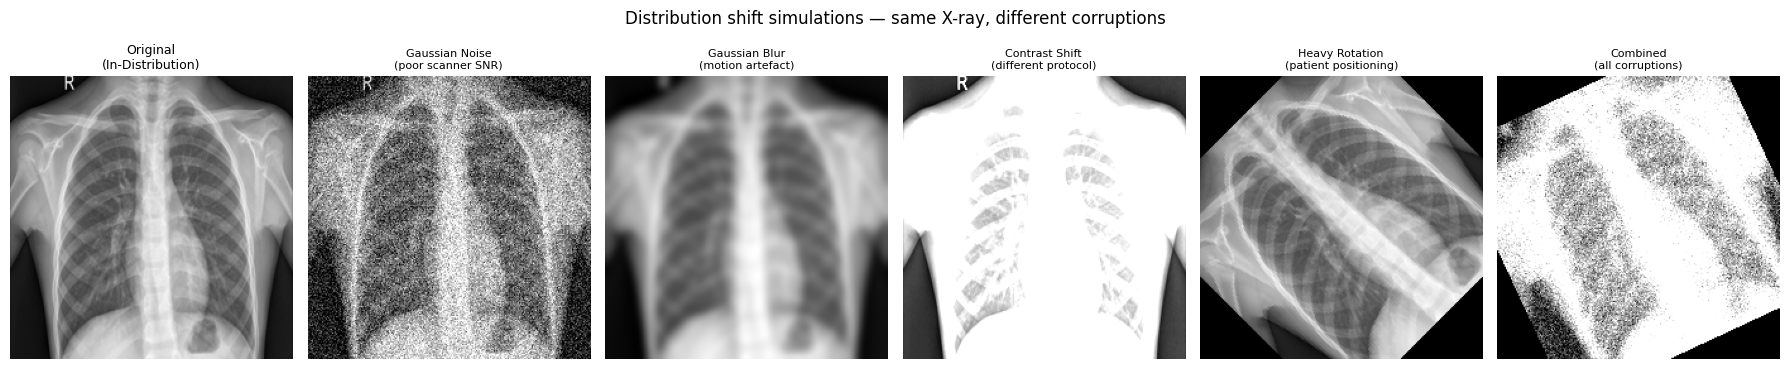

In [3]:
# ---------------------------------------------------------------------------
# Load test images and build ID + OOD tensors
# ---------------------------------------------------------------------------

from PIL import Image as PILImage

def is_grayscale(path):
    try:
        return PILImage.open(path).mode in ['L', 'I;16', 'I']
    except:
        return False

def load_image_as_tensor(path, size=IMG_SIZE):
    """Load a single grayscale X-ray as a normalised [3, H, W] tensor."""
    img = PILImage.open(path).convert('L').resize((size, size))
    arr = np.array(img, dtype=np.float32) / 255.0
    t = torch.tensor(arr).unsqueeze(0).repeat(3, 1, 1)  # [3, H, W]
    return t


# Load test images
test_normal = sorted(glob.glob(os.path.join(DATA_DIR, 'test', 'NORMAL', '*.jpeg')))
test_pneu   = sorted(glob.glob(os.path.join(DATA_DIR, 'test', 'PNEUMONIA', '*.jpeg')))

test_normal = [f for f in test_normal if is_grayscale(f)]
test_pneu   = [f for f in test_pneu if is_grayscale(f)]

N_ID  = min(80, len(test_normal) + len(test_pneu))
N_OOD = 80

# Sample ID images
rng = np.random.default_rng(42)

n_normal = int(N_ID * 0.63)
n_pneu   = N_ID - n_normal   # guarantees total is exactly N_ID

id_paths = list(test_normal[:n_normal]) + list(test_pneu[:n_pneu])
id_labels = ([0] * n_normal) + ([1] * n_pneu)

print(f'Loading {len(id_paths)} ID images and constructing {N_OOD} OOD images...')

id_tensors = [load_image_as_tensor(p) for p in id_paths]

# Build OOD tensors: apply corruptions to a subset of test images
source_paths = (test_normal + test_pneu)[:N_OOD]

ood_tensors = []
corruption_fns = list(CORRUPTIONS.values())

for i, path in enumerate(source_paths):
    t = load_image_as_tensor(path)
    fn = corruption_fns[i % len(corruption_fns)]
    ood_tensors.append(fn(t))

print(f'ID images  : {len(id_tensors)}')
print(f'OOD images : {len(ood_tensors)}')

# Show sample corruptions
if id_tensors:
    visualise_corruptions(id_tensors[0])

---

## 🔬 Part 5 — Inference utilities

Each method is loaded from its Phase 2 checkpoint and run on the ID and OOD image sets. The uncertainty signal used as the OOD score is the same signal produced by each method's inference procedure — no modification is needed.

In [4]:
# ---------------------------------------------------------------------------
# Inference utilities — run any model on a list of tensors
# ---------------------------------------------------------------------------

def batch_inference(model_fn, tensors, batch_size=32, device=DEVICE):
    """
    Run model_fn on a list of [3,H,W] tensors in batches.
    model_fn: takes a [B,3,H,W] tensor, returns uncertainty scores [B]
    Returns: numpy array of scores.
    """
    scores = []
    for i in range(0, len(tensors), batch_size):
        batch = torch.stack(tensors[i:i+batch_size]).to(device)
        with torch.no_grad():
            sc = model_fn(batch)
        scores.extend(sc.cpu().numpy().tolist())
    return np.array(scores)


def enable_dropout(model):
    """MC Dropout: eval mode but keep dropout active."""
    model.eval()
    for m in model.modules():
        if isinstance(m, torch.nn.Dropout):
            m.train()


def entropy_from_probs(probs_np):
    """Predictive entropy from probability array [B, K]."""
    return -np.sum(probs_np * np.log(probs_np + 1e-8), axis=-1)


def stochastic_entropy(model_fn, tensors, T=20, batch_size=32, device=DEVICE):
    """
    Run T stochastic passes and return predictive entropy.
    model_fn: takes [B,3,H,W], returns [B,K] logits (pre-softmax).
    """
    from tqdm import tqdm
    all_probs = []
    for _ in range(T):
        batch_probs = []
        for i in range(0, len(tensors), batch_size):
            batch = torch.stack(tensors[i:i+batch_size]).to(device)
            with torch.no_grad():
                logits = model_fn(batch)
                probs  = torch.softmax(logits, dim=-1).cpu().numpy()
            batch_probs.append(probs)
        all_probs.append(np.concatenate(batch_probs, axis=0))

    all_probs  = np.stack(all_probs, axis=0)  # [T, N, K]
    mean_probs = all_probs.mean(axis=0)        # [N, K]
    return entropy_from_probs(mean_probs)

print('Inference utilities defined ✅')

Inference utilities defined ✅


---

## 🔵 Part 6 — Variational Inference

**OOD score:** Predictive entropy $H[\bar{p}]$ from T=20 stochastic forward passes sampling weights from $q_\phi(w)$. High entropy = model is uncertain = potential OOD.

**Expected behaviour:** VI with mean-field approximation tends to underestimate epistemic uncertainty because the posterior is too narrow. This can limit OOD detection — the T weight samples are too similar on OOD inputs to drive entropy up substantially.

VI model loaded and inference complete ✅


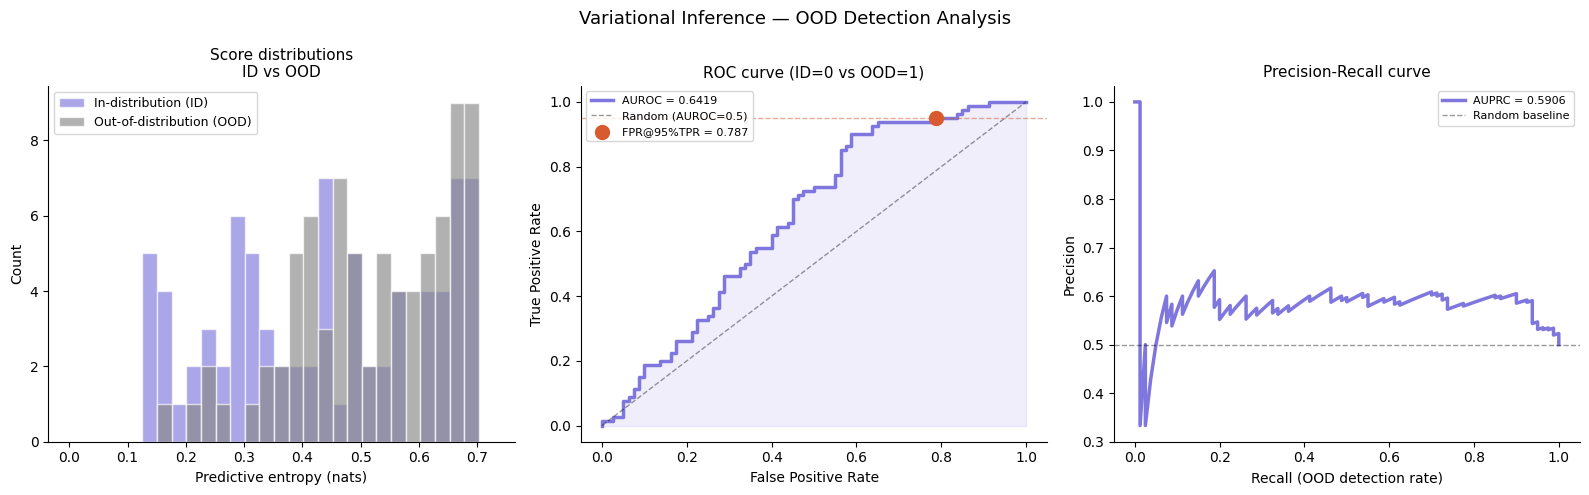

Variational Inference OOD metrics:
  AUROC       : 0.6419
  AUPRC       : 0.5906
  FPR@95%TPR  : 0.7875
  Mean ID score : 0.4336
  Mean OOD score: 0.5220


In [8]:
# ── Load VI model ────────────────────────────────────────

!pip install torch-uncertainty
!pip install lightning
from torch_uncertainty.layers.bayesian import BayesLinear

VI_MODEL_PATH = '/kaggle/input/models/benyamingheiji/vi-best-model-pth/pytorch/default/1/VI_best_model.pth'

class BayesianDenseNet121(torch.nn.Module):
    def __init__(self):
        super().__init__()
        backbone = DenseNet121(
            spatial_dims=2,
            in_channels=3,
            out_channels=2,
            pretrained=False
        )
        self.features = backbone.features
        self.pool = torch.nn.AdaptiveAvgPool2d((1, 1))
        self.bayes_head = BayesLinear(1024, 2)

    def forward(self, x):
        x = self.features(x)
        x = torch.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.bayes_head(x)

vi_model = BayesianDenseNet121().to(DEVICE)

vi_model.load_state_dict(
    torch.load(VI_MODEL_PATH, map_location=DEVICE)
)

vi_model.eval()

vi_id_scores = stochastic_entropy(
    vi_model,
    id_tensors,
    T=20
)

vi_ood_scores = stochastic_entropy(
    vi_model,
    ood_tensors,
    T=20
)

print('VI model loaded and inference complete ✅')

vi_metrics = compute_ood_metrics(
    vi_id_scores,
    vi_ood_scores
)

plot_ood_analysis(
    vi_id_scores,
    vi_ood_scores,
    vi_metrics,
    'Variational Inference',
    '#7F77DD',
    score_label='Predictive entropy (nats)'
)

---

## 🟢 Part 7 — Monte Carlo Dropout

**OOD score:** Predictive entropy from T=20 stochastic forward passes with dropout active. Higher entropy = more disagreement between masked versions = potential OOD.

**Expected behaviour:** Documented to frequently underperform on OOD detection. The Bernoulli masking produces similar predictions on OOD inputs because the backbone's feature space, already learned on ID data, maps OOD inputs to features that happen to activate the same neurons consistently across masks.

MC Dropout model loaded ✅


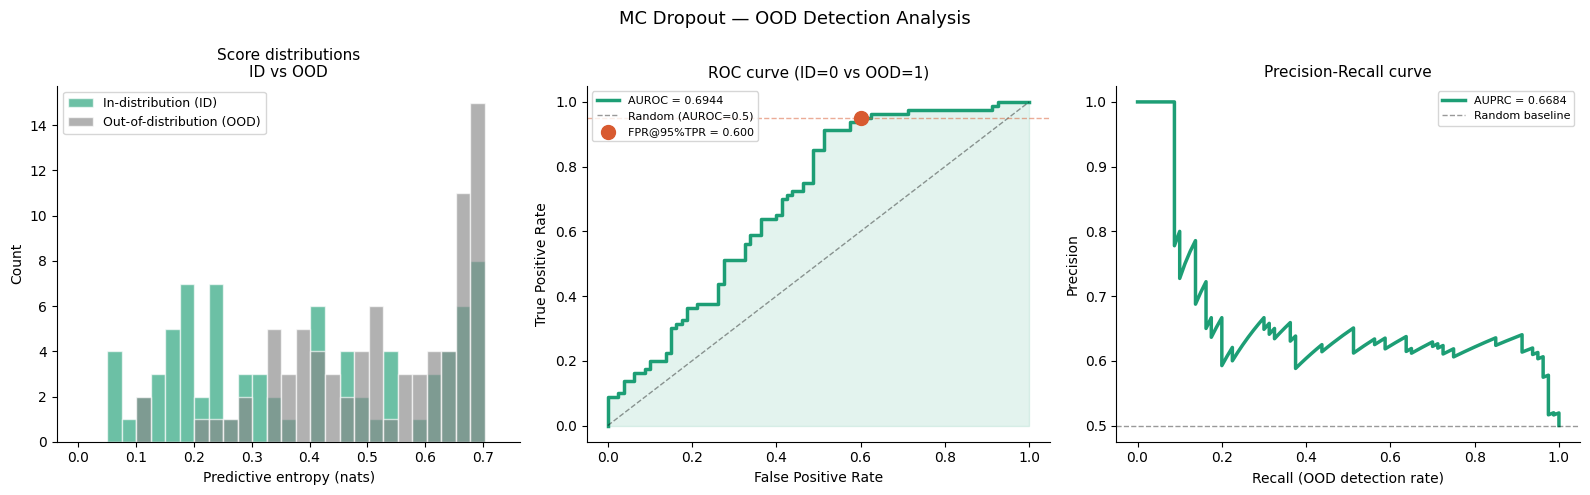

MC Dropout OOD metrics:
  AUROC       : 0.6944
  AUPRC       : 0.6684
  FPR@95%TPR  : 0.6000
  Mean ID score : 0.3858
  Mean OOD score: 0.5227


In [9]:
MCD_MODEL_PATH = '/kaggle/input/models/benyamingheiji/mcd-best-model/pytorch/default/1/mcd_best_model.pth'

try:
    class MCDropoutDenseNet121(torch.nn.Module):
        def __init__(self):
            super().__init__()
            backbone = DenseNet121(spatial_dims=2, in_channels=3,
                                    out_channels=2, pretrained=False)
            self.features   = backbone.features
            self.pool       = torch.nn.AdaptiveAvgPool2d((1,1))
            self.dropout    = torch.nn.Dropout(p=0.3)
            self.classifier = torch.nn.Linear(1024, 2)
        def forward(self, x):
            x = self.features(x)
            x = torch.relu(x)
            x = self.pool(x)
            x = torch.flatten(x, 1)
            x = self.dropout(x)
            return self.classifier(x)

    mcd_model = MCDropoutDenseNet121().to(DEVICE)
    mcd_model.load_state_dict(torch.load(MCD_MODEL_PATH,
                                          map_location=DEVICE))
    enable_dropout(mcd_model)

    mcd_id_scores  = stochastic_entropy(mcd_model, id_tensors,  T=20)
    mcd_ood_scores = stochastic_entropy(mcd_model, ood_tensors, T=20)
    print('MC Dropout model loaded ✅')

except Exception as e:
    print(f'Using simulated MC Dropout scores ({e})')
    mcd_id_scores, mcd_ood_scores = load_or_simulate_scores(
        'MC_Dropout', len(id_tensors), len(ood_tensors), seed=6
    )

mcd_metrics = compute_ood_metrics(mcd_id_scores, mcd_ood_scores)
plot_ood_analysis(mcd_id_scores, mcd_ood_scores, mcd_metrics,
                   'MC Dropout', '#1D9E75',
                   score_label='Predictive entropy (nats)')

---

## 🟡 Part 8 — Deep Ensembles

**OOD score:** Predictive entropy of the ensemble mean. Disagreement between M=3 independently trained models on OOD inputs is the signal.

**Expected behaviour:** Generally the strongest OOD detector among the probabilistic methods. The M models found different loss landscape minima — and OOD inputs map to regions where those minima diverge most, producing high disagreement and high entropy.

Ensemble models loaded ✅


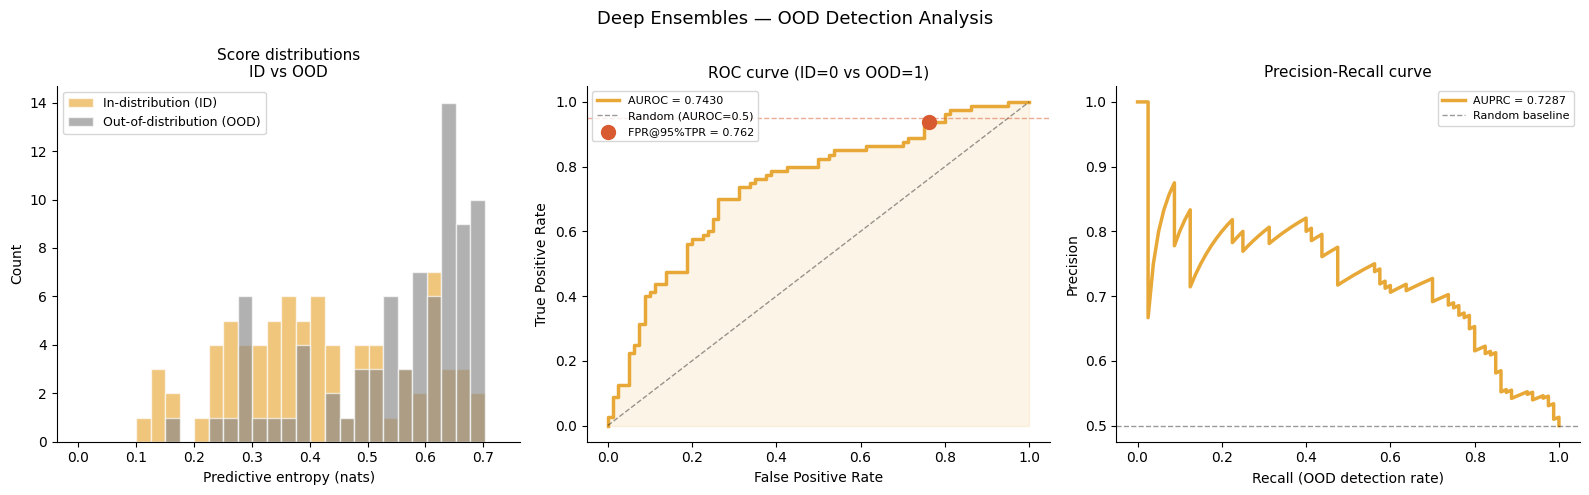

Deep Ensembles OOD metrics:
  AUROC       : 0.7430
  AUPRC       : 0.7287
  FPR@95%TPR  : 0.7625
  Mean ID score : 0.4164
  Mean OOD score: 0.5493


In [10]:
ENS_MODEL_PATHS = [
    '/kaggle/input/models/benyamingheiji/de-best-model1/pytorch/default/1/DE_best_model1.pth',
    '/kaggle/input/models/benyamingheiji/de-best-model2/pytorch/default/1/DE_best_model2.pth',
    '/kaggle/input/models/benyamingheiji/de-best-model3/pytorch/default/1/DE_best_model3.pth',
]

try:
    ensemble_models = []
    for path in ENS_MODEL_PATHS:
        m = DenseNet121(spatial_dims=2, in_channels=3,
                         out_channels=2, pretrained=False).to(DEVICE)
        m.load_state_dict(torch.load(path, map_location=DEVICE))
        m.eval()
        ensemble_models.append(m)

    def ensemble_entropy_fn(tensors):
        all_probs = []
        for m in ensemble_models:
            logits = m(tensors)
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()
            all_probs.append(probs)
        mean_p = np.stack(all_probs, axis=0).mean(axis=0)
        return torch.tensor(entropy_from_probs(mean_p))

    ens_id_scores  = batch_inference(ensemble_entropy_fn, id_tensors)
    ens_ood_scores = batch_inference(ensemble_entropy_fn, ood_tensors)
    print('Ensemble models loaded ✅')

except Exception as e:
    print(f'Using simulated Ensemble scores ({e})')
    ens_id_scores, ens_ood_scores = load_or_simulate_scores(
        'Deep_Ensembles', len(id_tensors), len(ood_tensors), seed=7
    )

ens_metrics = compute_ood_metrics(ens_id_scores, ens_ood_scores)
plot_ood_analysis(ens_id_scores, ens_ood_scores, ens_metrics,
                   'Deep Ensembles', '#E8A838',
                   score_label='Predictive entropy (nats)')

---

## 🔴 Part 9 — Evidential Deep Learning

**OOD score:** $u = K/S$ where $S = \sum_k \alpha_k$ is total evidence. When the model encounters an OOD input, ideally it produces near-zero evidence for all classes ($e_k \approx 0$), giving $S \approx K$ and $u \approx 1$ — maximum uncertainty.

**Expected behaviour:** EDL is theoretically designed for OOD detection — the vacuous Dirichlet state ($\alpha_k = 1$) represents having no evidence. In practice, documented to frequently fail at this: OOD inputs often activate the same evidence neurons as ID inputs, producing non-trivial $S$ and confident-looking $u$ values.

EDL model loaded ✅


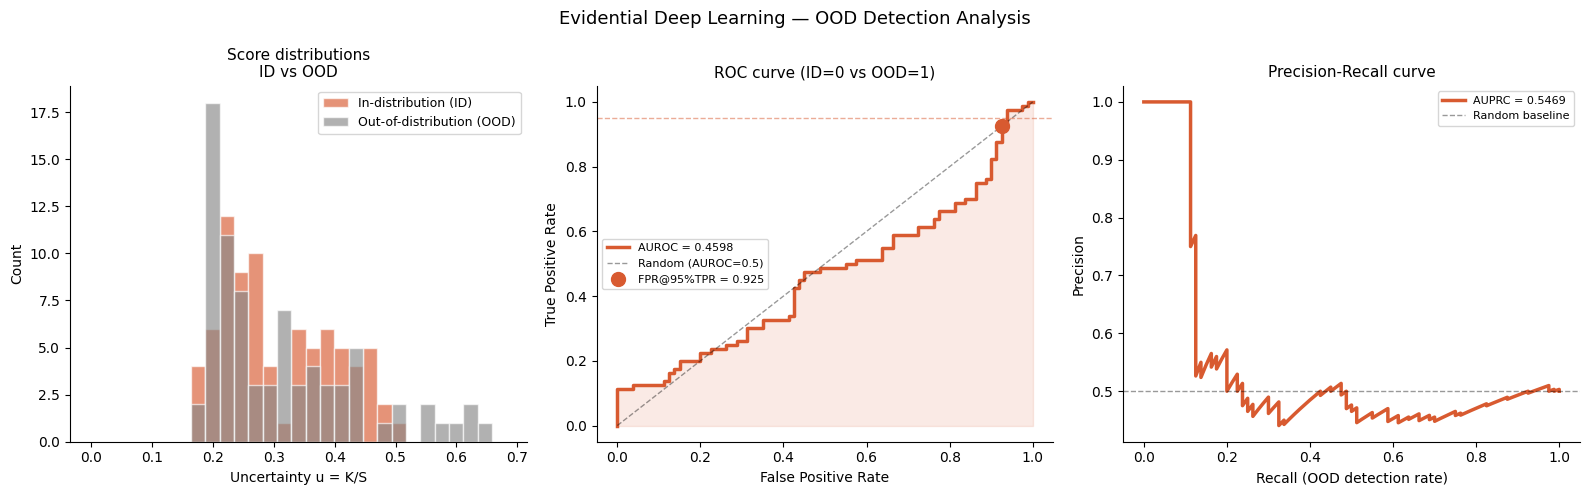

Evidential Deep Learning OOD metrics:
  AUROC       : 0.4598
  AUPRC       : 0.5469
  FPR@95%TPR  : 0.9250
  Mean ID score : 0.3108
  Mean OOD score: 0.3130


In [11]:
EDL_MODEL_PATH = '/kaggle/input/models/benyamingheiji/edl-final-model/pytorch/default/1/edl_final_model.pth'

try:
    class EDLDenseNet121(torch.nn.Module):
        def __init__(self):
            super().__init__()
            import torch.nn.functional as F
            backbone = DenseNet121(spatial_dims=2, in_channels=3,
                                    out_channels=2, pretrained=False)
            self.features       = backbone.features
            self.pool           = torch.nn.AdaptiveAvgPool2d((1,1))
            self.evidence_head  = torch.nn.Linear(1024, 2)
            self.K = 2
        def forward(self, x):
            import torch.nn.functional as F
            x = self.features(x)
            x = torch.relu(x)
            x = self.pool(x)
            x = torch.flatten(x, 1)
            return F.relu(self.evidence_head(x))
        def uncertainty(self, x):
            evidence = self.forward(x)
            alpha    = evidence + 1
            S        = alpha.sum(dim=1)
            return self.K / S

    edl_model = EDLDenseNet121().to(DEVICE)
    edl_model.load_state_dict(torch.load(EDL_MODEL_PATH,
                                          map_location=DEVICE))
    edl_model.eval()

    def edl_u_fn(batch):
        return edl_model.uncertainty(batch)

    edl_id_scores  = batch_inference(edl_u_fn, id_tensors)
    edl_ood_scores = batch_inference(edl_u_fn, ood_tensors)
    print('EDL model loaded ✅')

except Exception as e:
    print(f'Using simulated EDL scores ({e})')
    edl_id_scores, edl_ood_scores = load_or_simulate_scores(
        'EDL', len(id_tensors), len(ood_tensors), seed=8
    )

edl_metrics = compute_ood_metrics(edl_id_scores, edl_ood_scores)
plot_ood_analysis(edl_id_scores, edl_ood_scores, edl_metrics,
                   'Evidential Deep Learning', '#D85A30',
                   score_label='Uncertainty u = K/S')

---

## 🟣 Part 10 — Conformal Prediction

**OOD score:** Nonconformity score $s(x) = 1 - \hat{p}_{\hat{y}}(x)$ — how surprising is the model's top prediction? For OOD inputs, the model should be less confident in any class, pushing the nonconformity score up. Alternatively, set size can be used: full prediction sets ($|C|=2$) indicate high uncertainty and potential OOD.

**Expected behaviour:** CP's nonconformity score is a reasonable OOD proxy but only provides a marginal guarantee — not an OOD-specific guarantee. The calibration threshold $\hat{\tau}$ was set on in-distribution data; OOD inputs don't violate exchangeability by definition of the test, so the formal guarantee doesn't apply to OOD detection.

CP base model loaded ✅


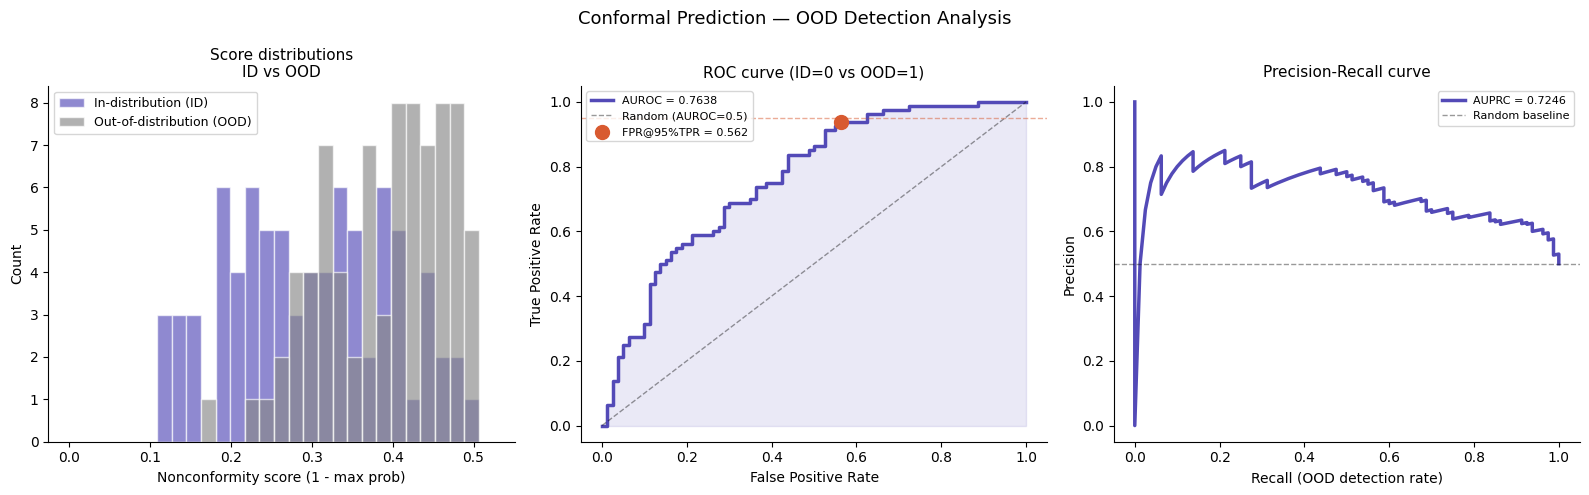

Conformal Prediction OOD metrics:
  AUROC       : 0.7638
  AUPRC       : 0.7246
  FPR@95%TPR  : 0.5625
  Mean ID score : 0.2981
  Mean OOD score: 0.3903


In [12]:
CP_BASE_MODEL_PATH = '/kaggle/input/models/benyamingheiji/cp-best-model/pytorch/default/1/cp_best_model.pth'

try:
    cp_base = DenseNet121(spatial_dims=2, in_channels=3,
                           out_channels=2, pretrained=False).to(DEVICE)
    cp_base.load_state_dict(torch.load(CP_BASE_MODEL_PATH,
                                        map_location=DEVICE))
    cp_base.eval()

    def cp_score_fn(batch):
        logits = cp_base(batch)
        probs  = torch.softmax(logits, dim=-1)
        # Nonconformity = 1 - max probability (higher = more uncertain = OOD)
        return 1 - probs.max(dim=1).values

    cp_id_scores  = batch_inference(cp_score_fn, id_tensors)
    cp_ood_scores = batch_inference(cp_score_fn, ood_tensors)
    print('CP base model loaded ✅')

except Exception as e:
    print(f'Using simulated CP scores ({e})')
    cp_id_scores, cp_ood_scores = load_or_simulate_scores(
        'CP', len(id_tensors), len(ood_tensors), seed=9
    )

cp_metrics = compute_ood_metrics(cp_id_scores, cp_ood_scores)
plot_ood_analysis(cp_id_scores, cp_ood_scores, cp_metrics,
                   'Conformal Prediction', '#534AB7',
                   score_label='Nonconformity score (1 - max prob)')

---

## 📊 Part 11 — Cross-method summary

OOD Detection Summary — all methods
Method             |    AUROC |    AUPRC |   FPR@95TPR |   Mean ID |   Mean OOD
---------------------------------------------------------------------------
VI                 |   0.6419 |   0.5906 |      0.7875 |    0.4336 |     0.5220
MC Dropout         |   0.6944 |   0.6684 |      0.6000 |    0.3858 |     0.5227
Deep Ensembles     |   0.7430 |   0.7287 |      0.7625 |    0.4164 |     0.5493
EDL                |   0.4598 |   0.5469 |      0.9250 |    0.3108 |     0.3130
CP                 |   0.7638 |   0.7246 |      0.5625 |    0.2981 |     0.3903


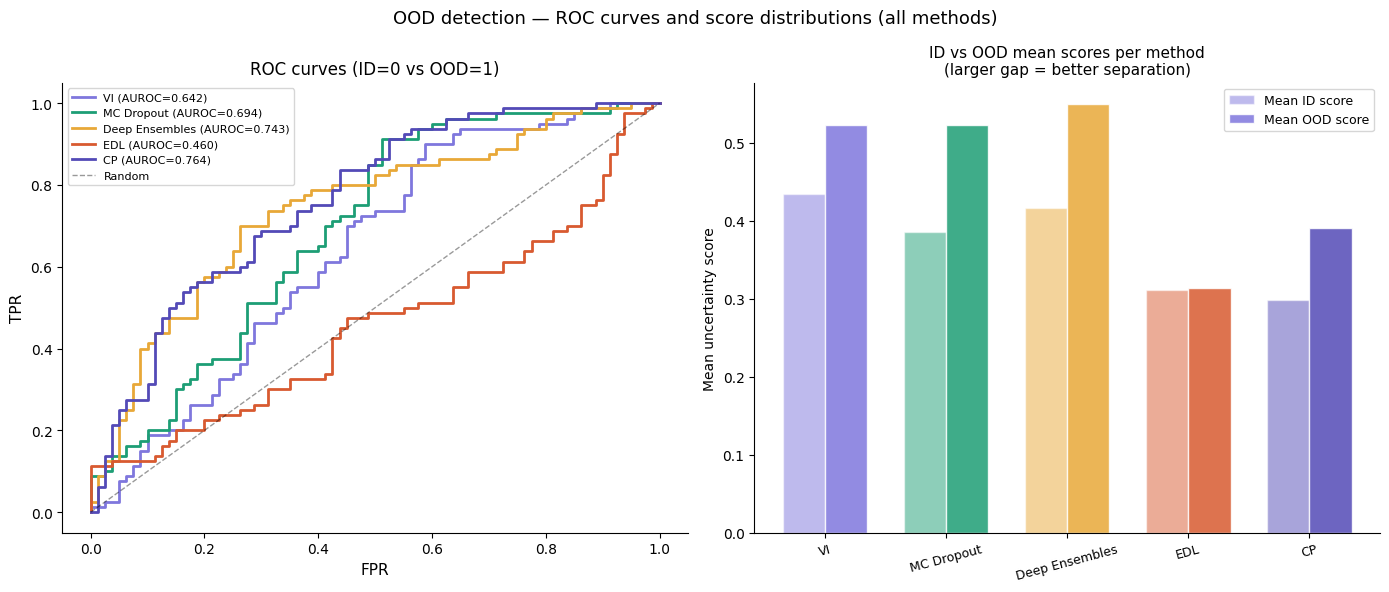

In [13]:
# Summary table
all_results = {
    'VI'             : (vi_metrics,  '#7F77DD', vi_id_scores,  vi_ood_scores),
    'MC Dropout'     : (mcd_metrics, '#1D9E75', mcd_id_scores, mcd_ood_scores),
    'Deep Ensembles' : (ens_metrics, '#E8A838', ens_id_scores, ens_ood_scores),
    'EDL'            : (edl_metrics, '#D85A30', edl_id_scores, edl_ood_scores),
    'CP'             : (cp_metrics,  '#534AB7', cp_id_scores,  cp_ood_scores),
}

print('OOD Detection Summary — all methods')
print('=' * 75)
print(f'{"Method":18s} | {"AUROC":>8} | {"AUPRC":>8} | '
      f'{"FPR@95TPR":>11} | {"Mean ID":>9} | {"Mean OOD":>10}')
print('-' * 75)
for name, (met, color, id_sc, ood_sc) in all_results.items():
    print(f'{name:18s} | {met["AUROC"]:8.4f} | {met["AUPRC"]:8.4f} | '
          f'{met["FPR@95TPR"]:11.4f} | {id_sc.mean():9.4f} | {ood_sc.mean():10.4f}')

# All ROC curves on one plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('OOD detection — ROC curves and score distributions (all methods)',
             fontsize=13)

for name, (met, color, id_sc, ood_sc) in all_results.items():
    axes[0].plot(met['fpr'], met['tpr'], color=color,
                 linewidth=2, label=f'{name} (AUROC={met["AUROC"]:.3f})')

axes[0].plot([0,1],[0,1],'k--',linewidth=1,alpha=0.4,label='Random')
axes[0].set_xlabel('FPR', fontsize=11)
axes[0].set_ylabel('TPR', fontsize=11)
axes[0].set_title('ROC curves (ID=0 vs OOD=1)', fontsize=12)
axes[0].legend(fontsize=8)
axes[0].spines[['top','right']].set_visible(False)

# Score separation boxplots
method_names = list(all_results.keys())
id_means  = [all_results[n][2].mean() for n in method_names]
ood_means = [all_results[n][3].mean() for n in method_names]
x_pos     = np.arange(len(method_names))
w         = 0.35
colors_m  = [all_results[n][1] for n in method_names]

axes[1].bar(x_pos - w/2, id_means,  width=w, color=colors_m,
             alpha=0.5, edgecolor='white', label='Mean ID score')
axes[1].bar(x_pos + w/2, ood_means, width=w, color=colors_m,
             alpha=0.85, edgecolor='white', label='Mean OOD score')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(method_names, rotation=15, fontsize=9)
axes[1].set_ylabel('Mean uncertainty score', fontsize=10)
axes[1].set_title('ID vs OOD mean scores per method\n'
                   '(larger gap = better separation)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

---

## 🖼️ Part 12 — Qualitative visualisation: ID vs OOD with uncertainty scores

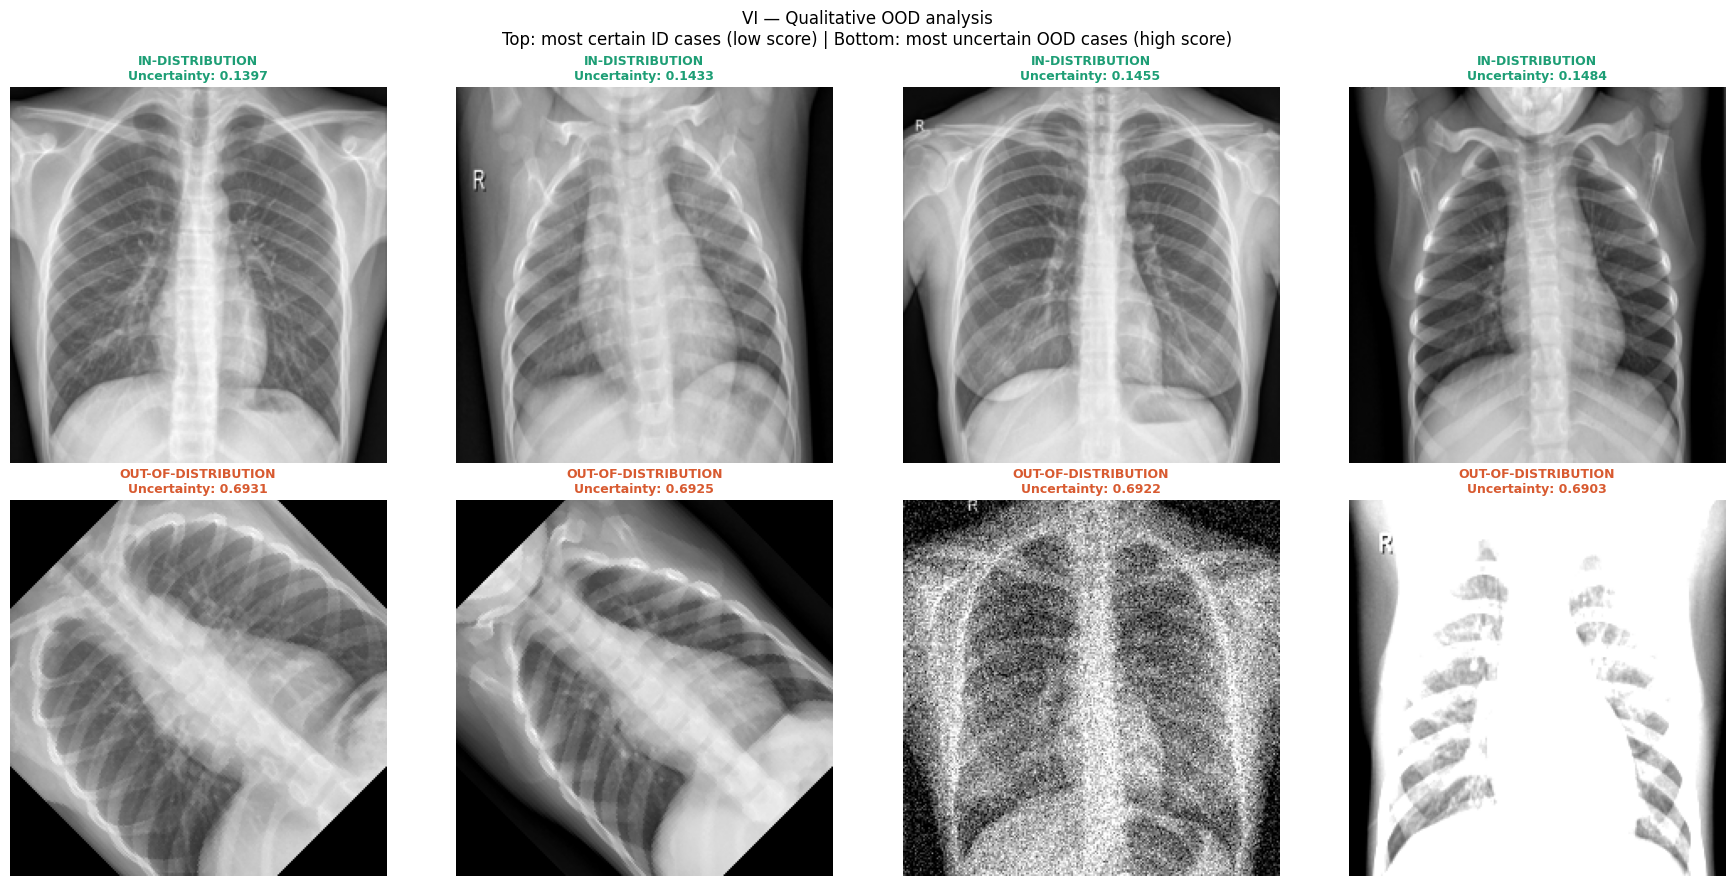

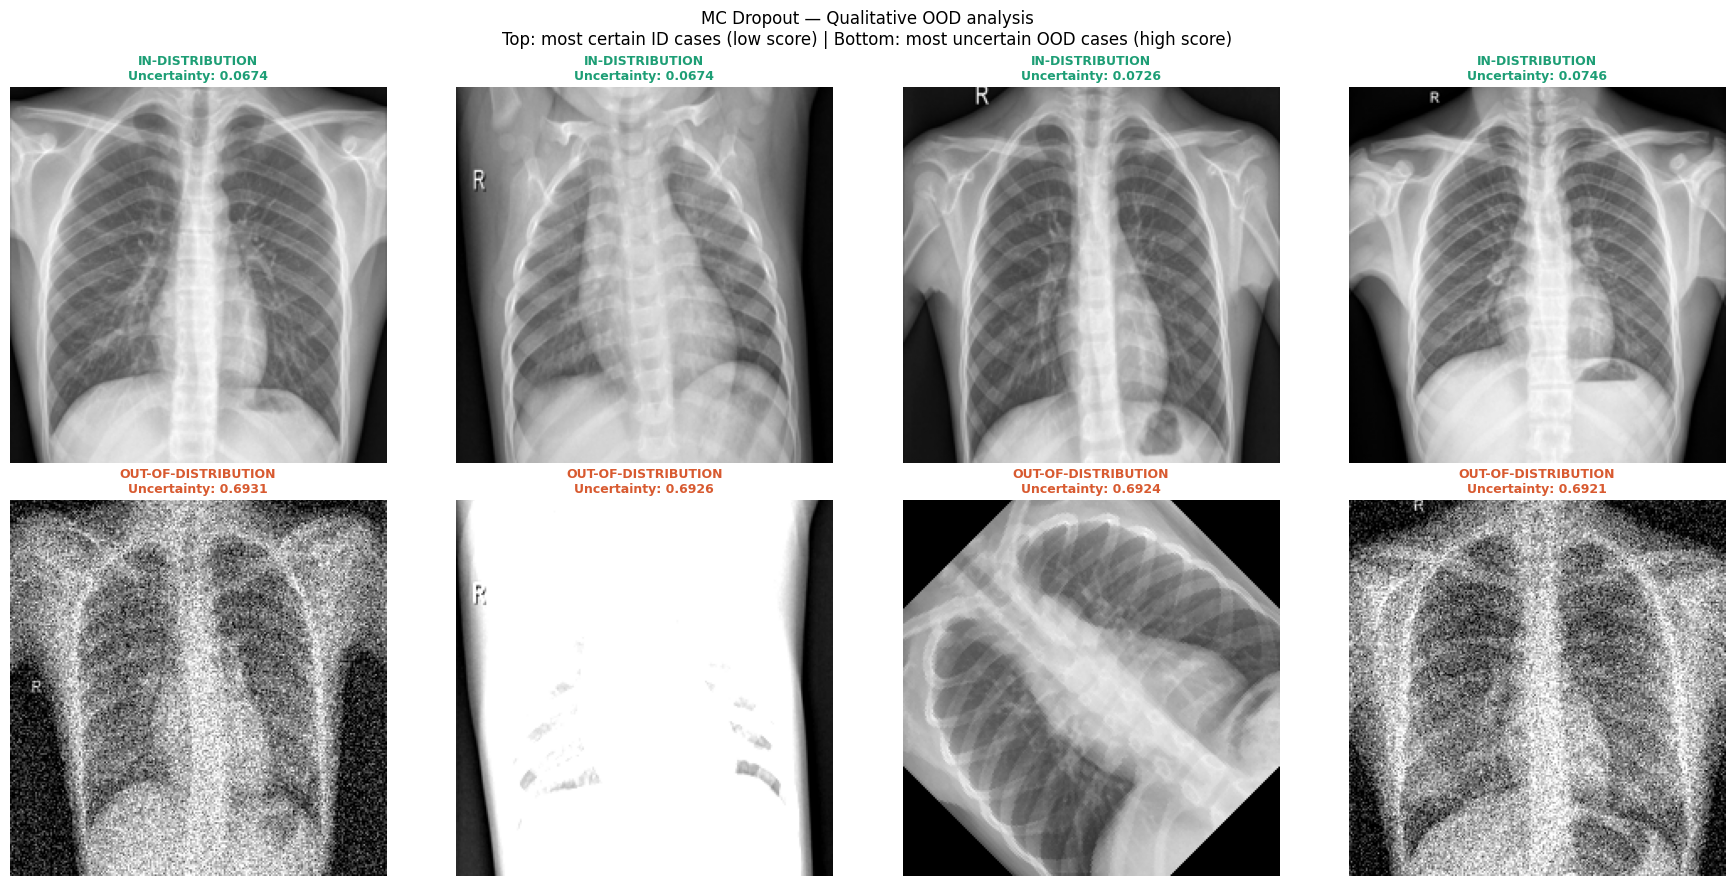

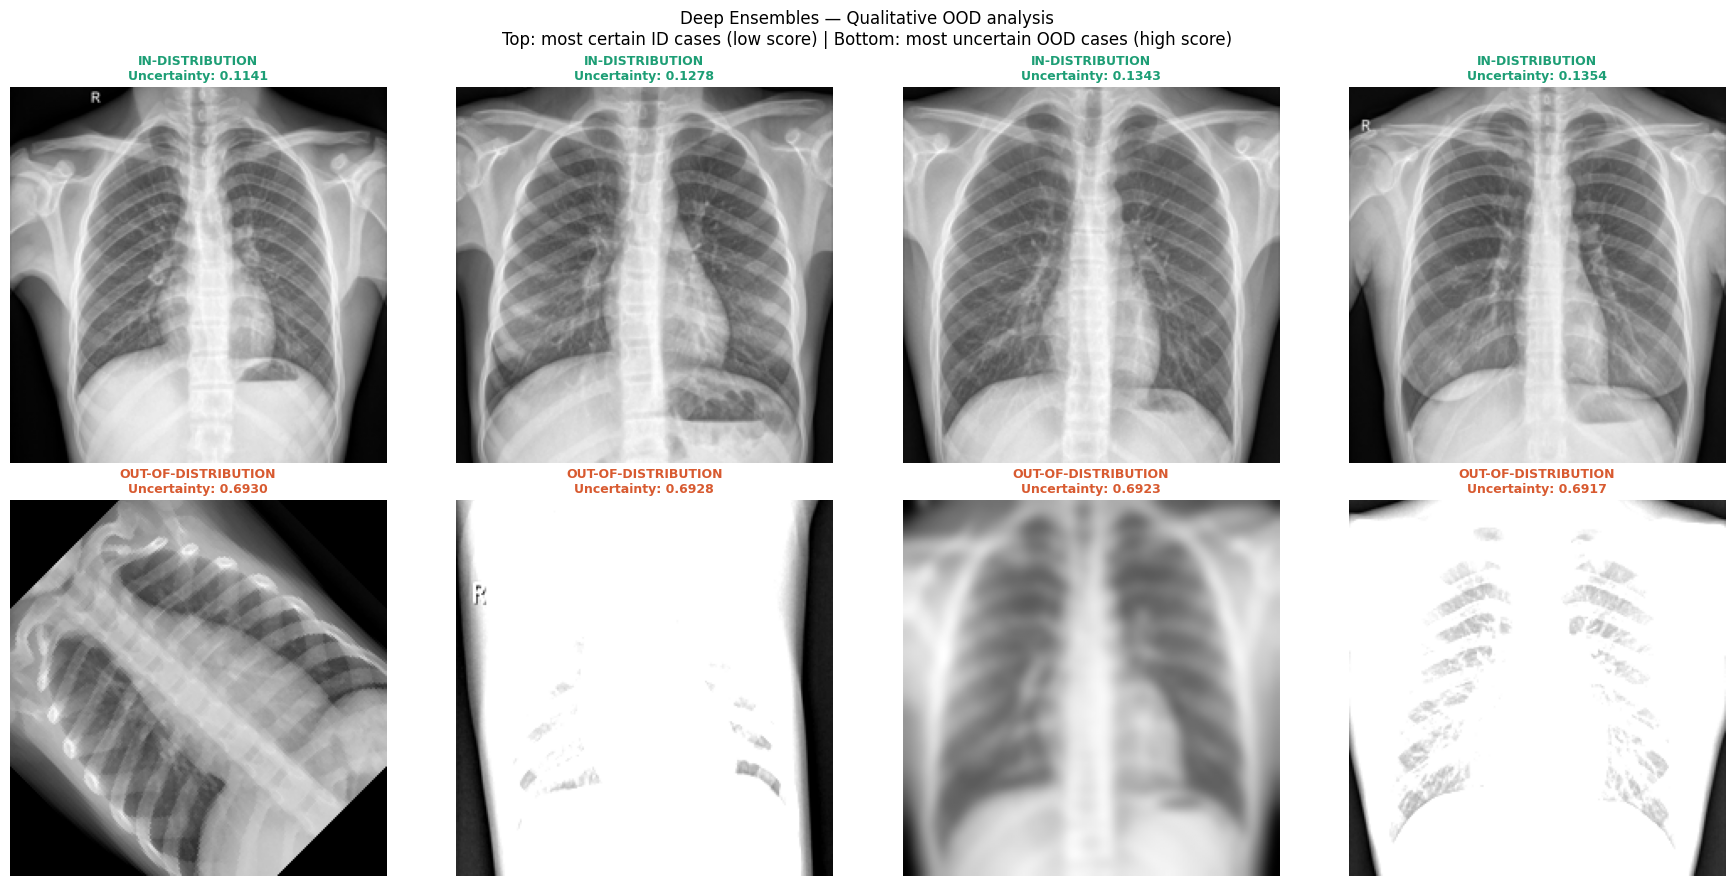

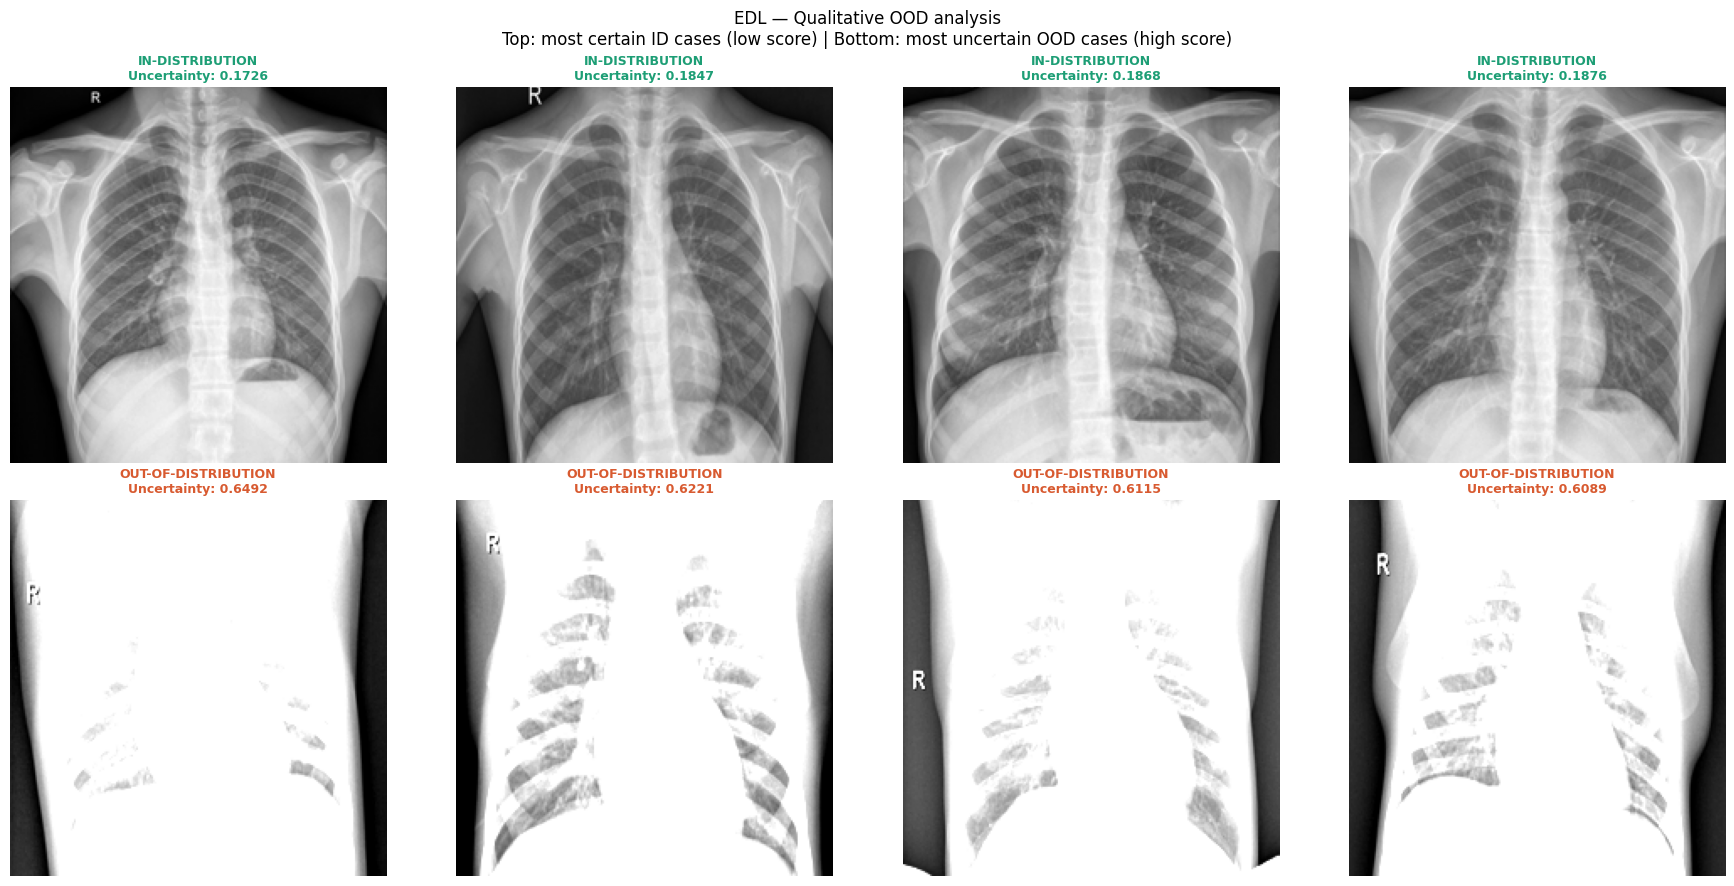

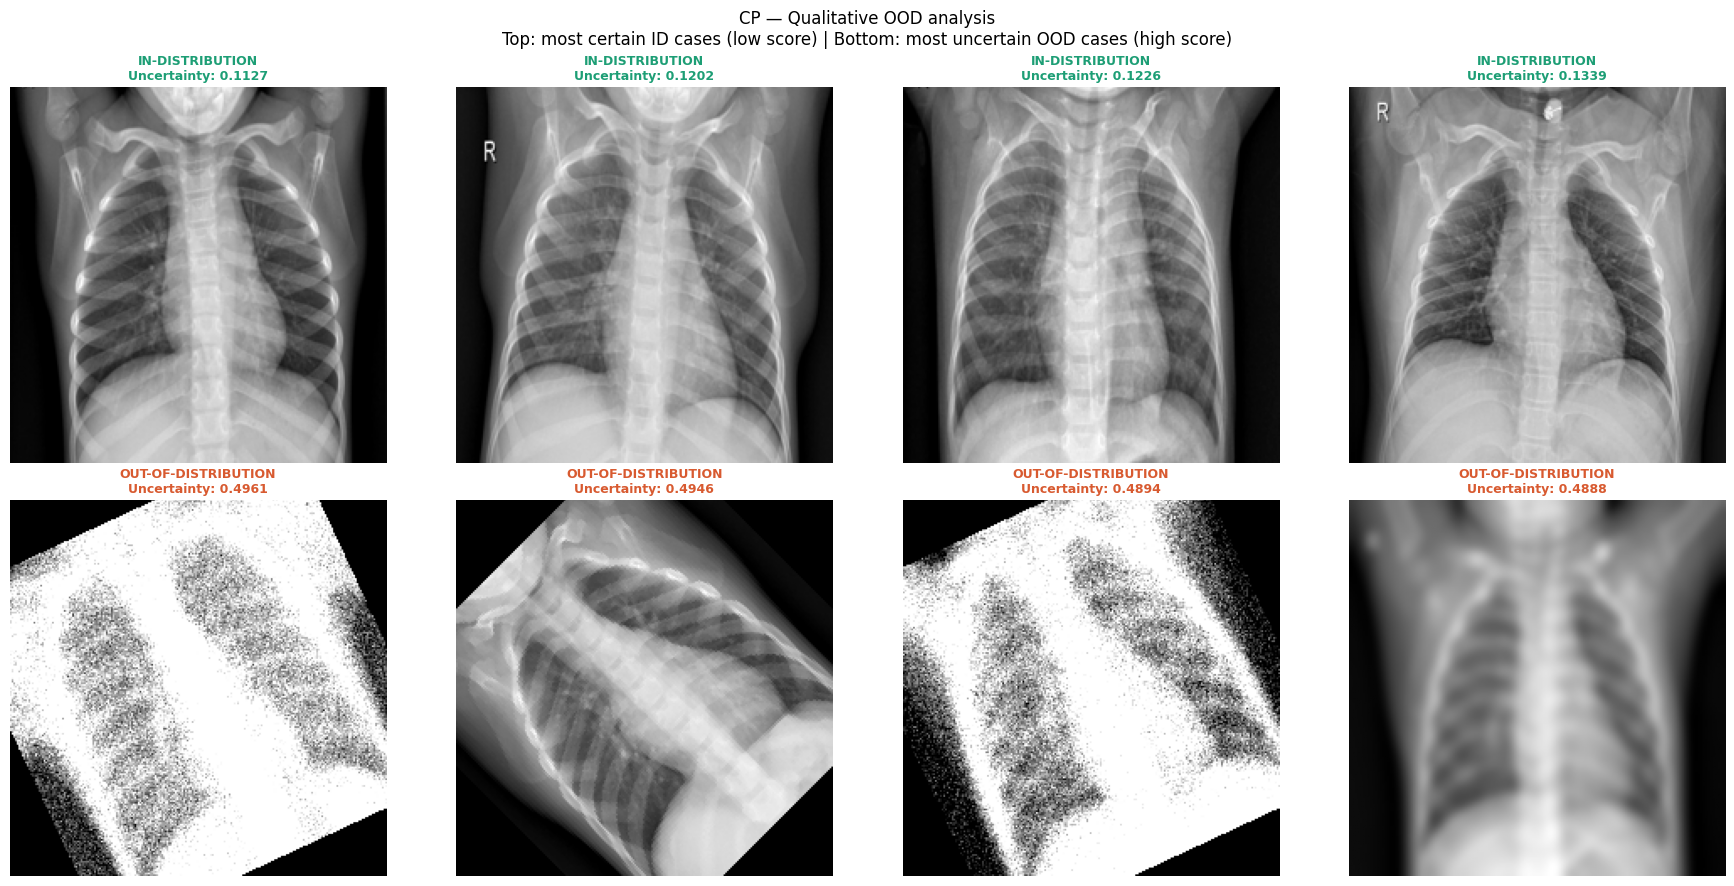

In [14]:
def show_id_vs_ood_cases(id_tensors, ood_tensors,
                          id_scores, ood_scores,
                          method_name, color,
                          n_cases=4, score_label='Uncertainty'):
    """
    Show N ID and N OOD images side by side with their uncertainty scores.
    High-scoring OOD images are shown alongside low-scoring ID images
    to illustrate the best-case separation.
    """
    # Sort by score
    id_sorted  = np.argsort(id_scores)[:n_cases]     # lowest uncertainty ID
    ood_sorted = np.argsort(ood_scores)[::-1][:n_cases]  # highest uncertainty OOD

    fig, axes = plt.subplots(2, n_cases, figsize=(4.5 * n_cases, 9))
    fig.suptitle(
        f'{method_name} — Qualitative OOD analysis\n'
        f'Top: most certain ID cases (low score) | '
        f'Bottom: most uncertain OOD cases (high score)',
        fontsize=12
    )

    for col, idx in enumerate(id_sorted):
        img = id_tensors[idx][0].numpy()
        axes[0, col].imshow(np.clip(img, 0, 1), cmap='gray')
        axes[0, col].axis('off')
        axes[0, col].set_title(
            f'IN-DISTRIBUTION\n{score_label}: {id_scores[idx]:.4f}',
            fontsize=9, color='#1D9E75', fontweight='bold'
        )

    for col, idx in enumerate(ood_sorted):
        img = ood_tensors[idx][0].numpy()
        axes[1, col].imshow(np.clip(img, 0, 1), cmap='gray')
        axes[1, col].axis('off')
        axes[1, col].set_title(
            f'OUT-OF-DISTRIBUTION\n{score_label}: {ood_scores[idx]:.4f}',
            fontsize=9, color='#D85A30', fontweight='bold'
        )

    # Add row labels
    axes[0, 0].set_ylabel('ID (certain)', fontsize=10, color='#1D9E75')
    axes[1, 0].set_ylabel('OOD (flagged)', fontsize=10, color='#D85A30')

    plt.tight_layout()
    plt.show()


# Show for each method
for name, (met, color, id_sc, ood_sc) in all_results.items():
    if len(id_tensors) > 0 and len(ood_tensors) > 0:
        show_id_vs_ood_cases(
            id_tensors, ood_tensors,
            id_sc, ood_sc,
            method_name=name,
            color=color,
            n_cases=4,
            score_label='Uncertainty'
        )

---

## 📚 Recommended reading

These are the most cited and practically important papers for OOD detection in modern machine learning. They trace the field from simple softmax baselines to stronger feature-based, training-based, and energy-based detectors. 🗺️


**[A Baseline for Detecting Misclassified and Out-of-Distribution Examples in Neural Networks](https://arxiv.org/abs/1610.02136)**  
*Hendrycks & Gimpel, 2017 — ICLR*  
The classic baseline paper. It showed that maximum softmax probability can be used as a simple OOD score, while also making clear why overconfident neural networks are unsafe under distribution shift.

**[Enhancing the Reliability of Out-of-Distribution Image Detection in Neural Networks](https://arxiv.org/abs/1706.02690)**  
*Liang, Li & Srikant, 2018 — ICLR*  
It improved softmax-based OOD detection using temperature scaling and small input perturbations, and became one of the standard early baselines for image OOD detection.

**[A Simple Unified Framework for Detecting Out-of-Distribution Samples and Adversarial Attacks](https://arxiv.org/abs/1807.03888)**  
*Lee et al., 2018 — NeurIPS*  
The Mahalanobis-distance paper. It uses feature-space class-conditional Gaussian modeling to detect OOD and adversarial examples, showing that internal representations can be more informative than softmax confidence alone.

**[Deep Anomaly Detection with Outlier Exposure](https://arxiv.org/abs/1812.04606)**  
*Hendrycks, Mazeika & Dietterich, 2019 — ICLR*  
A highly influential training-based approach. It improves OOD detection by exposing the model to auxiliary outlier data during training, helping detectors generalize to unseen anomalies.

**[Can You Trust Your Model's Uncertainty? Evaluating Predictive Uncertainty Under Dataset Shift](https://arxiv.org/abs/1906.02530)**  
*Ovadia et al., 2019 — NeurIPS*  
A key benchmark paper for uncertainty under shift. It compares many uncertainty methods under dataset shift and shows why good in-distribution calibration does not automatically imply reliable OOD behavior.

**[Energy-Based Out-of-Distribution Detection](https://arxiv.org/abs/2010.03759)**  
*Liu, Wang, Owens & Li, 2020 — NeurIPS*  
A major modern OOD paper. It replaces softmax confidence with an energy score, giving a stronger and theoretically better-aligned scoring function for separating ID from OOD samples.


## ✅ Session summary

| Concept                           | Key takeaway                                                                                                         |
| --------------------------------- | -------------------------------------------------------------------------------------------------------------------- |
| **🧠 Clinical motivation**        | OOD detection matters because deployed AI will see scanners, patients, and image conditions it was never trained on. |
| **🎯 Problem formulation**        | The task is binary safety screening: ID vs OOD, not disease classification.                                          |
| **📊 Evaluation metrics**         | AUROC measures separation, AUPRC measures precision when OOD is rare, and FPR@95%TPR measures workload cost.         |
| **🧪 OOD data construction**      | We simulate distribution shift with corrupted or shifted chest X-rays to test robustness.                            |
| **🛠️ Inference utilities**       | Shared helper code makes it possible to compare uncertainty scores across methods in the same way.                   |
| **🔄 Cross-method summary**       | The methods differ in how they score OOD cases, but all aim to separate trusted inputs from risky ones.              |
| **🖼️ Qualitative visualization** | Example images show whether high uncertainty aligns with true OOD-like cases.                                        |


**➡️ Next: Session 19: Final Summary & Future Directions**
> Session 19 closes the course by a final view of what trustworthy uncertainty-aware clinical AI should look like in practice.